In [10]:
import pandas as pd
import openpyxl
from datetime import timedelta

from datetime import datetime
import folium
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_filtered_final = pd.read_excel('OEFA_AND_OSINERGMIN_CURATED_FINAL.xlsx')

In [3]:
df_filtered_final['UNIDAD2'].value_counts()

UNIDAD2
LITROS      22
GALONES     18
BARRILES    17
0            5
BLS          3
GAL          1
N.E.         1
Name: count, dtype: int64

In [4]:
df_filtered_final['GALONES']

0           2.00
1         133.00
2          11.19
3           0.00
4         600.00
         ...    
62       1003.29
63    1652964.00
64          0.00
65          0.50
66        270.30
Name: GALONES, Length: 67, dtype: float64

In [5]:
import pandas as pd

# Asumimos que ya tienes tu dataframe df_filtered_final

# Función para convertir el valor de 'GALONES' dependiendo de 'UNIDAD2'
def convertir_galones(row):
    if row['UNIDAD2'] in ['BARRILES', 'BLS']:
        return row['GALONES'] * 42.000001
    elif row['UNIDAD2'] == 'LITROS':
        return row['GALONES'] * 0.2641720524
    else:
        return row['GALONES']

# Aplicar la función a cada fila para modificar la columna 'GALONES'
df_filtered_final['GALONES'] = df_filtered_final.apply(convertir_galones, axis=1)

In [6]:
df_filtered_final

,ADMINISTRADO,UNIDAD,FECHA DE EMERGENCIA AMBIENTAL,REGION,ZONA,ESTE,NORTE,TIPO,CANTIDAD,GALONES,...,TIPO3,DATOS,LAT,LON,datetime,coordinates,Original index,geometry,bbox,bbox_converted
0,PETRÓLEOS DEL PERÚ - PETROPERU S.A.,REFINERÍA TALARA,2012-02-16,PIURA,17.0,468654.0,9494226.0,SLOP (AGUA CON HIDROARBUROS),2,84.000002,...,AGUA,OEFA,-81.282592,-4.575743,2012-02-16T00:00:00Z/2012-02-29T23:59:59Z,"(-4.575742681270687, -81.28259214604834)",1,POINT (-81.28259214604834 -4.575742681270687),"[-81.50259214604826, -4.695742681270687, -81.2...","[[[-81.26259214604825, -4.695742681270687], [-..."
1,PETRÓLEOS DEL PERÚ - PETROPERU S.A.,REFINERÍA TALARA,2015-03-14,PIURA,17.0,468726.0,9494463.0,IFO 380,133,133.000000,...,AGUA DE MAR,OEFA,-81.281942,-4.573599,2015-03-14T00:00:00Z/2015-03-27T23:59:59Z,"(-4.573598887022488, -81.28194221451692)",7,POINT (-81.28194221451692 -4.573598887022488),"[-81.50194221451683, -4.693598887022488, -81.2...","[[[-81.26194221451682, -4.693598887022488], [-..."
2,CONSORCIO TERMINALES,TERMINAL ILO,2016-01-05,MOQUEGUA,19.0,251807.0,8048701.0,DIÉSEL B5,11.19,469.980011,...,"SUELO, AGUA",OEFA,-71.339177,-17.634633,2016-01-05T00:00:00Z/2016-01-18T23:59:59Z,"(-17.63463327894718, -71.33917659476346)",9,POINT (-71.33917659476346 -17.63463327894718),"[-71.55417659476338, -17.754633278947182, -71....","[[[-71.31417659476337, -17.754633278947182], [..."
3,PETRÓLEOS DEL PERÚ - PETROPERU S.A.,PLANTA DE VENTAS TALARA,2016-05-19,PIURA,17.0,469558.0,9491950.0,GLP,N.E.,0.000000,...,N.E.,OEFA,-81.274450,-4.596336,2016-05-19T00:00:00Z/2016-06-01T23:59:59Z,"(-4.596335979083023, -81.27445027923514)",12,POINT (-81.27445027923514 -4.596335979083023),"[-81.50445027923504, -4.7163359790830235, -81....","[[[-81.26445027923504, -4.7163359790830235], [..."
4,CONSORCIO TERMINALES,TERMINAL ILO,2016-08-08,MOQUEGUA,19.0,251797.0,8048705.0,DIÉSEL B5,600,25200.000600,...,PLAYA EL DIABLO,OEFA,-71.339270,-17.634596,2016-08-08T00:00:00Z/2016-08-21T23:59:59Z,"(-17.63459603566273, -71.33927031931913)",15,POINT (-71.33927031931913 -17.63459603566273),"[-71.55427031931904, -17.754596035662733, -71....","[[[-71.31427031931904, -17.754596035662733], [..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,SAVIA PERÚ S.A.,Oleoducto principal Batería 1 - PTS (Siches),NaT,PIURA,NaN,NaN,NaN,Petróleo,1003.29 lts,265.041178,...,NaN,OSINERGMIN,-81.098439,-4.511137,2021-01-21T00:00:00Z/2021-02-03T23:59:59Z,"('-4.5111366', '-81.0984392')",os_18,NaN,"[-81.31518919999982, -4.517886600000001, -81.2...","[[[-81.29168919999981, -4.517886600000001], [-..."
63,REFINERIA LA PAMPILLA S.A.A.,"Terminal N° 2 (Latitud 11° 55.9’S, Longitud 07...",NaT,Lima,NaN,NaN,NaN,Petróleo,1652964.0 lts,436666.892423,...,NaN,OSINERGMIN,-77.112674,-12.045290,2022-01-15T00:00:00Z/2022-01-28T23:59:59Z,"('-12.045289940133868', '-77.11267352226777')",os_19,NaN,"[-77.16942352226773, -12.052039940133866, -77....","[[[-77.14592352226772, -12.052039940133866], [..."
64,Savia Perú S.A.,"Plataforma PN14 , Peña Negra Mar",NaT,Piura,NaN,NaN,NaN,Petróleo,NO SE DETERMINÓ,0.000000,...,NaN,OSINERGMIN,-81.098439,-4.511137,2022-01-26T00:00:00Z/2022-02-08T23:59:59Z,"('-4.5111366', '-81.0984392')",os_20,NaN,"[-81.31518919999982, -4.517886600000001, -81.2...","[[[-81.29168919999981, -4.517886600000001], [-..."
65,PETROLEOS DEL PERU - PETROPERU S.A.,Terminal Submarino Multiboyas de Refinería Talara,NaT,PIURA,NaN,NaN,NaN,Petróleo,0.5 lts,0.132086,...,NaN,OSINERGMIN,-81.098439,-4.511137,2022-08-14T00:00:00Z/2022-08-27T23:59:59Z,"('-4.5111366', '-81.0984392')",os_21,NaN,"[-81.31518919999982, -4.517886600000001, -81.2...","[[[-81.29168919999981, -4.517886600000001], [-..."


In [7]:
peru_shapefile = gpd.read_file("DEPARTAMENTOS.shp")

In [8]:
# Plot the unified region and the coordinates
if peru_shapefile.crs is None:
    peru_shapefile.set_crs(epsg=4326, inplace=True)
elif peru_shapefile.crs.to_epsg() != 4326:
    peru_shapefile = peru_shapefile.to_crs(epsg=4326)
# Merge all individual states into one unified region
peru_region = peru_shapefile.unary_union

# Convert the merged region back into a GeoDataFrame
peru_gdf = gpd.GeoDataFrame(gpd.GeoSeries(peru_region), columns=['geometry'], crs="EPSG:4326")

# Convert coordinates to GeoDataFrame with the same CRS
df_filtered_final['geometry'] = df_filtered_final.apply(lambda row: Point(row['LAT'], row['LON']), axis=1)
geo_df = gpd.GeoDataFrame(df_filtered_final, geometry='geometry', crs="EPSG:4326")
geo_df = geo_df.drop(index=63)

C:\Users\user\AppData\Local\Temp\ipykernel_17052\1067488374.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  peru_region = peru_shapefile.unary_union


In [15]:
geo_df['galones_bin'].value_counts()

galones_bin
NO SE DETERMINÓ    26
0-10               13
100-1k             12
10-100             10
10k-50k             3
1k-10k              2
Name: count, dtype: int64

In [14]:
geo_df[geo_df['galones_bin']=='10k-50k']

,ADMINISTRADO,UNIDAD,FECHA DE EMERGENCIA AMBIENTAL,REGION,ZONA,ESTE,NORTE,TIPO,CANTIDAD,GALONES,...,LON,datetime,coordinates,Original index,geometry,bbox,bbox_converted,galones_bin,color,marker_size
4,CONSORCIO TERMINALES,TERMINAL ILO,2016-08-08,MOQUEGUA,19.0,251797.0,8048705.0,DIÉSEL B5,600,25200.000600,...,-17.634596,2016-08-08T00:00:00Z/2016-08-21T23:59:59Z,"(-17.63459603566273, -71.33927031931913)",15,POINT (-71.33927 -17.6346),"[-71.55427031931904, -17.754596035662733, -71....","[[[-71.31427031931904, -17.754596035662733], [...",10k-50k,midnightblue,500
9,REFINERÍA LA PAMPILLA S.A.A.,REFINERÍA LA PAMPILLA,2022-01-24,CALLAO,18.0,265619.0,8680762.0,PETROLEO,10397,436674.010397,...,-11.925613,2022-01-24T00:00:00Z/2022-02-06T23:59:59Z,"(-11.92561329271703, -77.15201335781732)",54,POINT (-77.15201 -11.92561),"[-77.35701335781725, -12.045613292717029, -77....","[[[-77.11701335781724, -12.045613292717029], [...",10k-50k,midnightblue,500
10,REFINERÍA LA PAMPILLA S.A.A.,REFINERÍA LA PAMPILLA,2022-01-15,CALLAO,18.0,265619.0,8680762.0,PETROLEO,10397,436674.010397,...,-11.925613,2022-01-15T00:00:00Z/2022-01-28T23:59:59Z,"(-11.92561329271703, -77.15201335781732)",55,POINT (-77.15201 -11.92561),"[-77.35701335781725, -12.045613292717029, -77....","[[[-77.11701335781724, -12.045613292717029], [...",10k-50k,midnightblue,500



Categorization of GALONES:
galones_bin
NO SE DETERMINÓ    26
0-10               13
100-1k             12
10-100             10
10k-50k             3
1k-10k              2
Name: count, dtype: int64

Color Assignment:
       galones_bin         color
0           10-100          blue
1           100-1k      darkblue
2           100-1k      darkblue
3  NO SE DETERMINÓ        violet
4          10k-50k  midnightblue

Marker Size Assignment:
       galones_bin  marker_size
0           10-100          200
1           100-1k          300
2           100-1k          300
3  NO SE DETERMINÓ           50
4          10k-50k          500


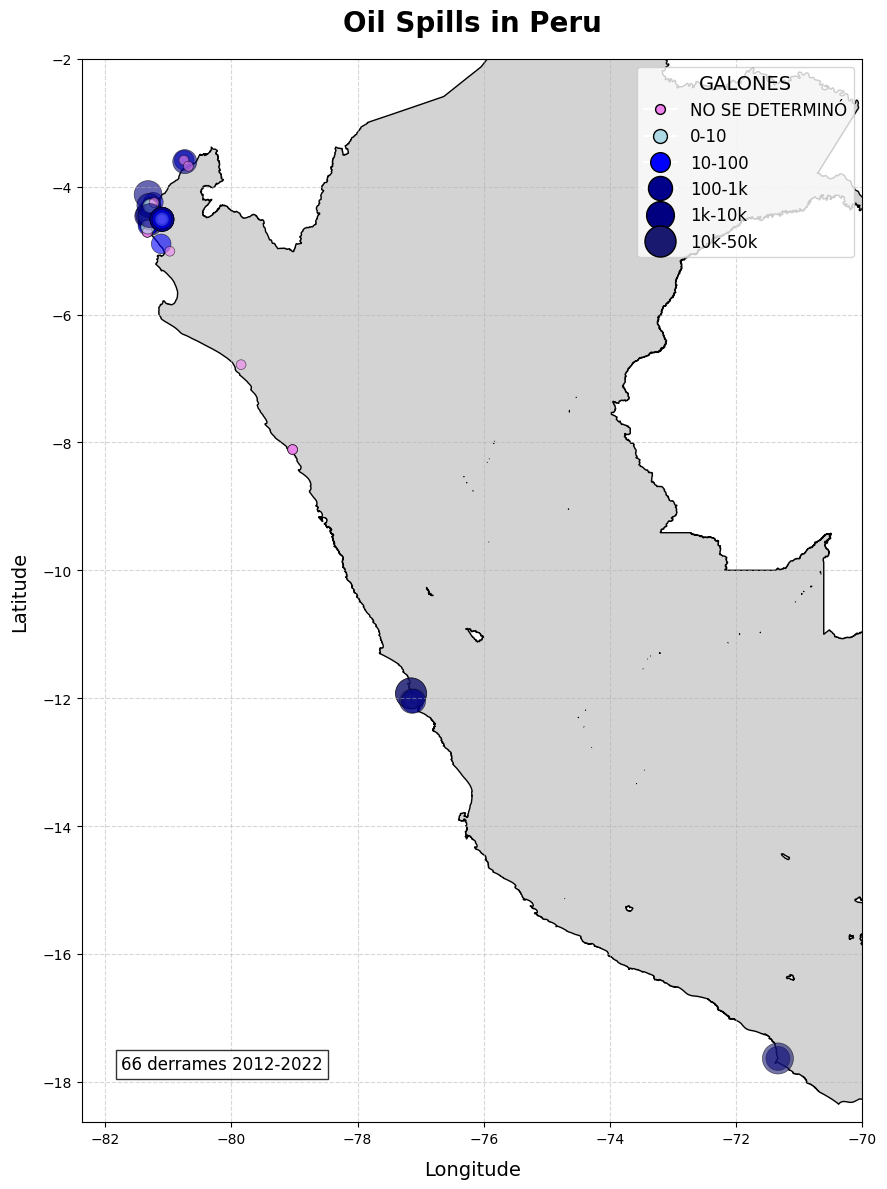

In [12]:
# Define bins and labels
from matplotlib.lines import Line2D
bins = [0, 10, 100, 1000, 10000, 500000]  # Correct bin edges
labels = ['0-10', '10-100', '100-1k', '1k-10k', '10k-50k']  # Corresponding labels

# Initialize 'galones_bin' with 'NO SE DETERMINÓ'
geo_df['galones_bin'] = 'NO SE DETERMINÓ'

# Create a mask for spills with GALONES > 0
mask = geo_df['GALONES'] > 0

# Categorize GALONES using pd.cut for spills with GALONES > 0
geo_df.loc[mask, 'galones_bin'] = pd.cut(
    geo_df.loc[mask, 'GALONES'],
    bins=bins,
    labels=labels,          # Use the defined labels
    include_lowest=True
)

# Verify the categorization
print("\nCategorization of GALONES:")
print(geo_df['galones_bin'].value_counts(dropna=False))

# ---------------------------
# 4. Assign Colors to Each Bin
# ---------------------------

# Define colors for each category
colors = {
    'NO SE DETERMINÓ': 'violet',
    '0-10': 'lightblue',
    '10-100': 'blue',
    '100-1k': 'darkblue',
    '1k-10k': 'navy',
    '10k-50k': 'midnightblue'
}

# Assign colors based on 'galones_bin'
geo_df['color'] = geo_df['galones_bin'].map(colors)

# Verify color assignment
print("\nColor Assignment:")
print(geo_df[['galones_bin', 'color']].head())

# ---------------------------
# 5. Assign Marker Sizes Based on Bins
# ---------------------------

# Define marker sizes for each category
size_mapping = {
    'NO SE DETERMINÓ': 50,      # Smallest size for undefined spills
    '0-10': 100,                # Slightly larger
    '10-100': 200,              # Medium size
    '100-1k': 300,              # Larger
    '1k-10k': 400,              # Even larger
    '10k-50k': 500              # Largest size for highest spills
}

# Assign marker sizes based on 'galones_bin'
geo_df['marker_size'] = geo_df['galones_bin'].map(size_mapping)

# Verify the marker_size assignment
print("\nMarker Size Assignment:")
print(geo_df[['galones_bin', 'marker_size']].head())
# Create the plot
fig, ax = plt.subplots(figsize=(15, 12))

# Plot the base map of Peru
peru_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot the oil spill locations
scatter = ax.scatter(
    geo_df['LAT'],  # X-axis as per user instruction
    geo_df['LON'],  # Y-axis as per user instruction
    s=geo_df['marker_size'],
    c=geo_df['color'],
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)

# Add a title and labels
ax.set_title('Oil Spills in Peru', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=14, labelpad=10)
ax.set_ylabel('Latitude', fontsize=14, labelpad=10)

# Enhance grid
ax.grid(True, linestyle='--', alpha=0.5)

# ---------------------------
# 8. Create Custom Legend for GALONES Categories
# ---------------------------

# Define the desired order for the legend
desired_order = ['NO SE DETERMINÓ', '0-10', '10-100', '100-1k', '1k-10k', '10k-50k']

# Filter the desired_order to include only existing categories in the data
sorted_unique_bins = [label for label in desired_order if label in geo_df['galones_bin'].unique()]

# Create legend handles based on the sorted_unique_bins
legend_handles = []
for label in sorted_unique_bins:
    size = size_mapping[label]
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor=colors[label], markeredgecolor='k', markersize=np.sqrt(size))
    )

# Add the legend to the plot
ax.legend(
    handles=legend_handles,
    title='GALONES',
    loc='upper right',
    scatterpoints=1,
    fontsize=12,
    title_fontsize=14
)

# ---------------------------
# 9. Add Text Box with Total Spills and Date Range
# ---------------------------

# Add a text box at the bottom left with "66 derrames 2012-2022"
ax.text(
    0.05, 0.05,  # Position in axes fraction (5% from left, 5% from bottom)
    "66 derrames 2012-2022",
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'),
    transform=ax.transAxes
)

# ---------------------------
# 10. Adjust Plot Limits with Buffer
# ---------------------------

# Adjust plot limits to include all data points with buffer
buffer_x = 1  # degrees buffer for LAT
buffer_y = 1  # degrees buffer for LON
ax.set_xlim(geo_df['LAT'].min() - buffer_x, geo_df['LAT'].max() + buffer_x)
ax.set_ylim(geo_df['LON'].min() - buffer_y, geo_df['LON'].max() + buffer_y)

# Remove axis ticks for clarity
ax.set_xticks(np.arange(int(geo_df['LAT'].min() - buffer_x), int(geo_df['LAT'].max() + buffer_x) + 1, 2))
ax.set_yticks(np.arange(int(geo_df['LON'].min() - buffer_y), int(geo_df['LON'].max() + buffer_y) + 1, 2))

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
fig.savefig('oil_spills_map_peru2.png', dpi=300, bbox_inches='tight')

In [ ]:
import folium
import folium.plugins as plugins

def create_map(location, zoom, geo_df, region_name):
    # Create the map centered on the region
    m = folium.Map(location=location, zoom_start=zoom, tiles='OpenStreetMap')
    
    # Add the boundary of Peru (using the given shapefile)
    folium.GeoJson(
        peru_shapefile,
        name='Peru',
        style_function=lambda x: {'color': 'black', 'fillColor': 'lightgrey', 'weight': 1, 'fillOpacity': 0.1}
    ).add_to(m)
    html = '''
    <span style="size: 50px; background-color: lightblue; ">
    <i class="fa-solid fa-tint"> </i>
    </span>
    '''
    # Add the markers for oil spills in the region without using Marker Cluster
    for index, row in geo_df.iterrows():
        icon = folium.DivIcon(
            icon_size=(3000,1000),
            icon_anchor=(5,5),
            html=html )
        folium.Marker(
            location=[row['LON'], row['LAT']],
            popup=f"Oil Spill {row['Original index']}",
            icon=icon
        ).add_to(m)

    # Add a title to the map
    title_html = '''
        <div style="position: fixed; 
                    top: 10px; left: 200px; width: 200px; height: 80px; 
                    background-color: white; z-index:9999; font-size:20px;
                    border:2px solid grey; padding: 10px;">
            <b>Norte del Perú: Piura</b>
        </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    return m
    # Uncomment the next line to save each map to an HTML file
    # m.save(f'{region_name}_map.html')

# Coordinates and zoom levels for different clusters of oil spills
north_map = create_map(location=[-4.5, -81.3], zoom=9.75, geo_df=geo_df, region_name='north')
north_map
